<a href="https://colab.research.google.com/github/fsananna/3_Cloud/blob/main/7july.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
config.py — All paths and hyperparameters.
Save this to: /content/drive/MyDrive/AllData/config.py
Never run this directly. Every other script imports from here.
"""
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path('/content/drive/MyDrive/AllData')

TRAIN_TSV  = BASE_DIR / 'SubtaskA_Train/train/subtask_a_train.tsv'
TRAIN_ROOT = BASE_DIR / 'SubtaskA_Train/train'

DEV_TSV    = BASE_DIR / 'SubtaskA_Dev/dev/subtask_a_dev.tsv'
DEV_ROOT   = BASE_DIR / 'SubtaskA_Dev/dev'

TEST_TSV   = BASE_DIR / 'test(labelled)/subtask_a_test.tsv'
TEST_ROOT  = BASE_DIR / 'test(labelled)'

MODEL_PATH   = BASE_DIR / 'best_model.pth'
HISTORY_PATH = BASE_DIR / 'history.json'
PLOTS_DIR    = BASE_DIR / 'plots'

# ── Fixed hyperparameters (professor requirements — never change) ──────────────
LR_BERT              = 2e-5
DROPOUT_PROB         = 0.2
BERT_UNFREEZE_EP     = 10
BERT_UNFREEZE_LAYERS = 3

# ── Training hyperparameters ──────────────────────────────────────────────────
LR_BASE             = 0.001   # FIXED — 0.01 causes gradient explosion
BATCH_SIZE          = 4
EPOCHS              = 50
WEIGHT_DECAY        = 5e-2
EARLY_STOP_PATIENCE = 10
LABEL_SMOOTH_ALPHA  = 0.1
MAX_LENGTH          = 64

# ── Model constants ───────────────────────────────────────────────────────────
EMBED_DIM  = 512
NUM_HEADS  = 2
BERT_MODEL = 'bert-base-uncased'

# ── Ground truth score mapping ────────────────────────────────────────────────
RANK_SCORE = {0: 1.0, 1: 0.8, 2: 0.6, 3: 0.4, 4: 0.2}

In [ ]:
"""
utils.py — Shared loss and evaluation functions.
Save this to: /content/drive/MyDrive/AllData/utils.py
Never run this directly.
"""
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import ndcg_score


def listnet_loss(pred, target, alpha=0.1):
    """
    ListNet ranking loss with label smoothing.
    pred   : [B, 5] model output logits
    target : [B, 5] ground truth scores
    Returns: scalar loss
    """
    if alpha > 0:
        uniform = torch.full_like(target, 1.0 / target.size(1))
        target  = (1.0 - alpha) * target + alpha * uniform
    pred_p   = F.softmax(pred,   dim=1)
    target_p = F.softmax(target, dim=1)
    return (-torch.sum(target_p * torch.log(pred_p + 1e-10), dim=1)).mean()


def evaluate_loader(model, loader, device):
    """
    Run inference over a DataLoader and return (ndcg, top1_accuracy).
    Returns two values: ndcg (float), acc (float)
    """
    model.eval()
    all_accs  = []
    all_ndcgs = []

    with torch.no_grad():
        for batch in loader:
            sent_ids, sent_mask, imgs, cap_ids, cap_mask, targets = batch
            sent_ids  = sent_ids.to(device)
            sent_mask = sent_mask.to(device)
            imgs      = imgs.to(device)
            cap_ids   = cap_ids.to(device)
            cap_mask  = cap_mask.to(device)

            out = model(sent_ids, sent_mask, imgs, cap_ids, cap_mask)

            logits_np  = out.cpu().numpy()
            targets_np = targets.numpy()

            all_accs.append(
                (np.argmax(logits_np, axis=1) == np.argmax(targets_np, axis=1))
                .astype(float).mean()
            )
            all_ndcgs.append(ndcg_score(targets_np, logits_np))

    return float(np.mean(all_ndcgs)), float(np.mean(all_accs))

In [ ]:
"""
dataset_loader.py — IdiomDataset (three-stream).
Save this to: /content/drive/MyDrive/AllData/dataset_loader.py
Never run this directly.

Returns a 6-tuple per item:
  sent_ids   [64]           sentence token ids
  sent_mask  [64]           sentence attention mask
  imgs       [5, 3,224,224] five image tensors
  cap_ids    [5, 64]        five caption token id tensors
  cap_mask   [5, 64]        five caption attention masks
  scores     [5]            ground truth relevance scores
"""
import ast
import torch
import pandas as pd
from torch.utils.data import Dataset
from torchvision import transforms as T
from transformers import BertTokenizer
from PIL import Image
from pathlib import Path


RANK_SCORE = {0: 1.0, 1: 0.8, 2: 0.6, 3: 0.4, 4: 0.2}
MAX_LENGTH = 64
BERT_MODEL = 'bert-base-uncased'


class IdiomDataset(Dataset):

    def __init__(self, dataframe, image_root,
                 augment=False, use_sentence_type=True):
        self.df                = dataframe.reset_index(drop=True)
        self.image_root        = Path(image_root)
        self.use_sentence_type = use_sentence_type
        self.tokenizer         = BertTokenizer.from_pretrained(BERT_MODEL)

        if augment:
            self.img_transform = T.Compose([
                T.Resize((256, 256)),
                T.RandomCrop((224, 224)),
                T.RandomHorizontalFlip(p=0.5),
                T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406],
                            std =[0.229, 0.224, 0.225])
            ])
        else:
            self.img_transform = T.Compose([
                T.Resize((224, 224)),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406],
                            std =[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.df)

    def _tok(self, text):
        """Tokenize one string → (input_ids [64], attention_mask [64])"""
        enc = self.tokenizer(
            text, padding='max_length', truncation=True,
            max_length=MAX_LENGTH, return_tensors='pt'
        )
        return enc['input_ids'].squeeze(0), enc['attention_mask'].squeeze(0)

    def _load_img(self, compound, name):
        """Load one image. Return zeros tensor on any failure."""
        if not name or name == 'nan':
            return torch.zeros(3, 224, 224)
        path = self.image_root / compound / name
        try:
            return self.img_transform(Image.open(path).convert('RGB'))
        except Exception:
            return torch.zeros(3, 224, 224)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        sentence = str(row['sentence']).strip()
        compound = str(row['compound']).strip()

        # ── Sentence text ──────────────────────────────────────────────
        if (self.use_sentence_type
                and 'sentence_type' in row.index
                and pd.notna(row['sentence_type'])):
            sent_type = str(row['sentence_type']).strip().capitalize()
            text_str  = f"{sentence} {sent_type}."
        else:
            text_str = sentence

        sent_ids, sent_mask = self._tok(text_str)

        # ── Images and captions ────────────────────────────────────────
        imgs, cap_ids_list, cap_mask_list = [], [], []

        for i in range(1, 6):
            # Image
            name = str(row.get(f'image{i}_name', '')).strip()
            imgs.append(self._load_img(compound, name))

            # Caption
            raw = row.get(f'image{i}_caption', '')
            cap = str(raw).strip() if pd.notna(raw) else ''
            c_ids, c_mask = self._tok(cap)
            cap_ids_list.append(c_ids)
            cap_mask_list.append(c_mask)

        # ── Scores ────────────────────────────────────────────────────
        scores    = torch.zeros(5)
        img_names = [str(row.get(f'image{i}_name', '')).strip()
                     for i in range(1, 6)]
        try:
            gt = ast.literal_eval(str(row['expected_order']))
            for rank, fname in enumerate(gt[:5]):
                if fname in img_names:
                    scores[img_names.index(fname)] = RANK_SCORE.get(rank, 0.0)
        except Exception:
            pass

        return (
            sent_ids,
            sent_mask,
            torch.stack(imgs),
            torch.stack(cap_ids_list),
            torch.stack(cap_mask_list),
            scores
        )

In [ ]:
"""
model_architecture.py — IdiomFusionModel (three-stream).
Save this to: /content/drive/MyDrive/AllData/model_architecture.py
Never run this directly.

Three streams:
  1. Sentence text  → shared BERT → [B, 1, 512]
  2. Raw images     → frozen ResNet50 → [B, 5, 512]
  3. Image captions → shared BERT → [B, 5, 512]
  Fusion → Cross-attention → Ranking head → scores [B, 5]
"""
import torch
import torch.nn as nn
from torchvision import models
from transformers import BertModel


BERT_MODEL           = 'bert-base-uncased'
EMBED_DIM            = 512
NUM_HEADS            = 2
DROPOUT_PROB         = 0.2
BERT_UNFREEZE_LAYERS = 3
MAX_LENGTH           = 64


class IdiomFusionModel(nn.Module):

    def __init__(self):
        super().__init__()

        # ── Shared BERT (sentence + captions) ─────────────────────────
        self.bert      = BertModel.from_pretrained(BERT_MODEL)
        self.sent_proj = nn.Linear(768, EMBED_DIM)
        self.cap_proj  = nn.Linear(768, EMBED_DIM)

        # ── Frozen ResNet-50 ───────────────────────────────────────────
        resnet = models.resnet50(weights='DEFAULT')
        self.vision_enc = nn.Sequential(*list(resnet.children())[:-1])
        for p in self.vision_enc.parameters():
            p.requires_grad = False          # always frozen
        self.vis_proj = nn.Linear(2048, EMBED_DIM)

        # ── Fusion: concat(visual, caption) → 512 ─────────────────────
        self.fusion_proj = nn.Linear(EMBED_DIM * 2, EMBED_DIM)

        # ── Cross-attention: Q=fused, K=sentence, V=sentence ──────────
        self.cross_attn = nn.MultiheadAttention(
            EMBED_DIM, num_heads=NUM_HEADS, batch_first=True)

        # ── Ranking head (Dropout=0.2 FIXED) ──────────────────────────
        self.ranking_head = nn.Sequential(
            nn.Linear(EMBED_DIM, 64),
            nn.ReLU(),
            nn.Dropout(DROPOUT_PROB),
            nn.Linear(64, 1)
        )

    def freeze_bert(self):
        for p in self.bert.parameters():
            p.requires_grad = False

    def unfreeze_bert_last_n(self, n=BERT_UNFREEZE_LAYERS):
        total = len(self.bert.encoder.layer)
        for i, layer in enumerate(self.bert.encoder.layer):
            if i >= total - n:
                for p in layer.parameters():
                    p.requires_grad = True
        for p in self.bert.pooler.parameters():
            p.requires_grad = True

    def trainable_bert_params(self):
        return [p for p in self.bert.parameters() if p.requires_grad]

    def forward(self, sent_ids, sent_mask, imgs, cap_ids, cap_mask):
        B = sent_ids.size(0)

        # Stream 1 — sentence
        sent_cls  = self.bert(sent_ids, sent_mask).last_hidden_state[:, 0, :]
        sent_feat = self.sent_proj(sent_cls).unsqueeze(1)      # [B, 1, 512]

        # Stream 2 — images (ResNet, always frozen)
        with torch.no_grad():
            vis_raw = self.vision_enc(
                imgs.view(B * 5, 3, 224, 224)
            ).squeeze(-1).squeeze(-1)                          # [B*5, 2048]
        vis_feat = self.vis_proj(vis_raw).view(B, 5, EMBED_DIM) # [B, 5, 512]

        # Stream 3 — captions (shared BERT)
        cap_cls  = self.bert(
            cap_ids.view(B * 5, MAX_LENGTH),
            cap_mask.view(B * 5, MAX_LENGTH)
        ).last_hidden_state[:, 0, :]                           # [B*5, 768]
        cap_feat = self.cap_proj(cap_cls).view(B, 5, EMBED_DIM) # [B, 5, 512]

        # Fusion — concat visual + caption then project
        fused_vc = self.fusion_proj(
            torch.cat([vis_feat, cap_feat], dim=-1)
        )                                                       # [B, 5, 512]

        # Cross-attention — Q=fused, K=sentence, V=sentence
        attn_out, _ = self.cross_attn(
            query=fused_vc,
            key=sent_feat,
            value=sent_feat
        )                                                       # [B, 5, 512]

        # Residual + ranking
        out = fused_vc + attn_out                              # [B, 5, 512]
        return self.ranking_head(out).squeeze(-1)              # [B, 5]

In [ ]:
import os
import sys
import importlib

drive_path = '/content/drive/MyDrive/AllData/'

# 1. Rename the files on your Google Drive
old_loader = os.path.join(drive_path, '01_dataset_loader.py')
new_loader = os.path.join(drive_path, 'dataset_loader.py')
if os.path.exists(old_loader):
    os.rename(old_loader, new_loader)
    print("✅ Renamed dataset_loader.py")

old_model = os.path.join(drive_path, '02_model_architecture.py')
new_model = os.path.join(drive_path, 'model_architecture.py')
if os.path.exists(old_model):
    os.rename(old_model, new_model)
    print("✅ Renamed model_architecture.py")

# 2. Clear Python's import cache so it sees the new names
importlib.invalidate_caches()
for mod in ['dataset_loader', 'model_architecture']:
    if mod in sys.modules:
        del sys.modules[mod]

print("\n🚀 Done! You can now run your run_training.py script.")

✅ Renamed dataset_loader.py
✅ Renamed model_architecture.py

🚀 Done! You can now run your run_training.py script.


In [ ]:
import os
import shutil

drive_path = '/content/drive/MyDrive/AllData'

# 1. Delete hidden cache to force Colab to read fresh files
pycache = os.path.join(drive_path, '__pycache__')
if os.path.exists(pycache):
    shutil.rmtree(pycache)
    print("🗑️ Deleted hidden __pycache__ folder.")

# 2. Force write the updated model architecture
model_content = """
import torch
import torch.nn as nn
from torchvision import models
from transformers import BertModel

BERT_MODEL           = 'bert-base-uncased'
EMBED_DIM            = 512
NUM_HEADS            = 2
DROPOUT_PROB         = 0.2
BERT_UNFREEZE_LAYERS = 3
MAX_LENGTH           = 64

class IdiomFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # ── Shared BERT (sentence + captions) ─────────────────────────
        self.bert      = BertModel.from_pretrained(BERT_MODEL)
        self.sent_proj = nn.Linear(768, EMBED_DIM)
        self.cap_proj  = nn.Linear(768, EMBED_DIM)

        # ── Frozen ResNet-50 ───────────────────────────────────────────
        resnet = models.resnet50(weights='DEFAULT')
        self.vision_enc = nn.Sequential(*list(resnet.children())[:-1])
        for p in self.vision_enc.parameters():
            p.requires_grad = False          # always frozen
        self.vis_proj = nn.Linear(2048, EMBED_DIM)

        # ── Fusion: concat(visual, caption) → 512 ─────────────────────
        self.fusion_proj = nn.Linear(EMBED_DIM * 2, EMBED_DIM)

        # ── Cross-attention: Q=fused, K=sentence, V=sentence ──────────
        self.cross_attn = nn.MultiheadAttention(
            EMBED_DIM, num_heads=NUM_HEADS, batch_first=True)

        # ── Ranking head (Dropout=0.2 FIXED) ──────────────────────────
        self.ranking_head = nn.Sequential(
            nn.Linear(EMBED_DIM, 64),
            nn.ReLU(),
            nn.Dropout(DROPOUT_PROB),
            nn.Linear(64, 1)
        )

    def freeze_bert(self):
        for p in self.bert.parameters():
            p.requires_grad = False

    def unfreeze_bert_last_n(self, n=BERT_UNFREEZE_LAYERS):
        total = len(self.bert.encoder.layer)
        for i, layer in enumerate(self.bert.encoder.layer):
            if i >= total - n:
                for p in layer.parameters():
                    p.requires_grad = True
        for p in self.bert.pooler.parameters():
            p.requires_grad = True

    def trainable_bert_params(self):
        return [p for p in self.bert.parameters() if p.requires_grad]

    def forward(self, sent_ids, sent_mask, imgs, cap_ids, cap_mask):
        B = sent_ids.size(0)

        # Stream 1 — sentence
        sent_cls  = self.bert(sent_ids, sent_mask).last_hidden_state[:, 0, :]
        sent_feat = self.sent_proj(sent_cls).unsqueeze(1)      # [B, 1, 512]

        # Stream 2 — images (ResNet, always frozen)
        with torch.no_grad():
            vis_raw = self.vision_enc(
                imgs.view(B * 5, 3, 224, 224)
            ).squeeze(-1).squeeze(-1)                          # [B*5, 2048]
        vis_feat = self.vis_proj(vis_raw).view(B, 5, EMBED_DIM) # [B, 5, 512]

        # Stream 3 — captions (shared BERT)
        cap_cls  = self.bert(
            cap_ids.view(B * 5, MAX_LENGTH),
            cap_mask.view(B * 5, MAX_LENGTH)
        ).last_hidden_state[:, 0, :]                           # [B*5, 768]
        cap_feat = self.cap_proj(cap_cls).view(B, 5, EMBED_DIM) # [B, 5, 512]

        # Fusion — concat visual + caption then project
        fused_vc = self.fusion_proj(
            torch.cat([vis_feat, cap_feat], dim=-1)
        )                                                       # [B, 5, 512]

        # Cross-attention — Q=fused, K=sentence, V=sentence
        attn_out, _ = self.cross_attn(
            query=fused_vc,
            key=sent_feat,
            value=sent_feat
        )                                                       # [B, 5, 512]

        # Residual + ranking
        out = fused_vc + attn_out                              # [B, 5, 512]
        return self.ranking_head(out).squeeze(-1)              # [B, 5]
"""

with open(os.path.join(drive_path, 'model_architecture.py'), 'w') as f:
    f.write(model_content.strip())

print("✅ File forcefully updated with freeze_bert() method!")

✅ File forcefully updated with freeze_bert() method!


In [ ]:
"""
================================================================================
 run_training.py  ← RUN THIS FIRST
 AdMIRe Three-Stream Model | Final Training
 Researcher: Farhana Sultana Ananna

 What this does:
   1. Trains on train set (70 rows), validates on dev set (15 rows)
   2. Uses LR_BASE=0.001, partial BERT unfreeze at epoch 10
   3. Saves best checkpoint to best_model.pth
   4. Saves training history to history.json
   5. Runs the same training twice:
        Pass 1 — WITH sentence type appended
        Pass 2 — WITHOUT sentence type appended
      The best checkpoint from Pass 1 (with ST) is what you use for evaluation.

 After this finishes → run run_evaluation.py
================================================================================
"""
import sys
import json
import shutil
import importlib

# ── Colab: add project folder to Python path ──────────────────────────────────
sys.path.insert(0, '/content/drive/MyDrive/AllData')
importlib.invalidate_caches()
for mod in ['config', 'utils', 'dataset_loader', 'model_architecture']:
    if mod in sys.modules:
        del sys.modules[mod]

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from pathlib import Path

from config import (
    TRAIN_TSV, TRAIN_ROOT, DEV_TSV, DEV_ROOT,
    MODEL_PATH, HISTORY_PATH,
    LR_BASE, LR_BERT, BATCH_SIZE, EPOCHS,
    WEIGHT_DECAY, EARLY_STOP_PATIENCE, LABEL_SMOOTH_ALPHA,
    BERT_UNFREEZE_EP, BERT_UNFREEZE_LAYERS, BASE_DIR
)
from utils import listnet_loss, evaluate_loader
from dataset_loader import IdiomDataset
from model_architecture import IdiomFusionModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')

# ─────────────────────────────────────────────────────────────────────────────
# TRAINING FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
def train(use_sentence_type, save_path):
    label = 'WITH sentence type' if use_sentence_type else 'WITHOUT sentence type'
    print(f'\n{"="*60}')
    print(f'  Training: {label}')
    print(f'{"="*60}')

    train_df = pd.read_csv(TRAIN_TSV, sep='\t')
    dev_df   = pd.read_csv(DEV_TSV,   sep='\t')
    print(f'  Train rows: {len(train_df)} | Dev rows: {len(dev_df)}')

    train_ds = IdiomDataset(train_df, TRAIN_ROOT,
                            augment=True,
                            use_sentence_type=use_sentence_type)
    dev_ds   = IdiomDataset(dev_df, DEV_ROOT,
                            augment=False,
                            use_sentence_type=use_sentence_type)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=2, pin_memory=False)
    dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=False)

    model = IdiomFusionModel().to(device)
    model.freeze_bert()

    optimizer = torch.optim.AdamW([
        {'params': model.sent_proj.parameters(),
         'lr': LR_BASE, 'weight_decay': WEIGHT_DECAY},
        {'params': model.cap_proj.parameters(),
         'lr': LR_BASE, 'weight_decay': WEIGHT_DECAY},
        {'params': model.vis_proj.parameters(),
         'lr': LR_BASE, 'weight_decay': WEIGHT_DECAY},
        {'params': model.fusion_proj.parameters(),
         'lr': LR_BASE, 'weight_decay': WEIGHT_DECAY},
        {'params': model.cross_attn.parameters(),
         'lr': LR_BASE, 'weight_decay': WEIGHT_DECAY},
        {'params': model.ranking_head.parameters(),
         'lr': LR_BASE, 'weight_decay': WEIGHT_DECAY},
    ])

    scheduler      = torch.optim.lr_scheduler.CosineAnnealingLR(
                        optimizer, T_max=EPOCHS)
    bert_added     = False
    best_combined  = -1.0
    patience_count = 0
    local_ckpt     = Path('/content/best_model_tmp.pth')

    history = {
        'train_loss': [],
        'val_ndcg':   [],
        'val_top1':   []
    }

    for epoch in range(1, EPOCHS + 1):

        # Partial BERT unfreeze at epoch 10
        if epoch == BERT_UNFREEZE_EP and not bert_added:
            model.unfreeze_bert_last_n(BERT_UNFREEZE_LAYERS)
            bert_params = model.trainable_bert_params()
            if bert_params:
                optimizer.add_param_group({
                    'params': bert_params,
                    'lr':     LR_BERT,
                    'weight_decay': WEIGHT_DECAY
                })
            bert_added = True
            print(f'  🔓 Epoch {epoch}: BERT last {BERT_UNFREEZE_LAYERS} '
                  f'layers unfrozen (lr={LR_BERT})')

        # ── Train one epoch ───────────────────────────────────────────
        model.train()
        epoch_loss = 0.0

        for batch in train_loader:
            sent_ids, sent_mask, imgs, cap_ids, cap_mask, targets = batch
            sent_ids  = sent_ids.to(device)
            sent_mask = sent_mask.to(device)
            imgs      = imgs.to(device)
            cap_ids   = cap_ids.to(device)
            cap_mask  = cap_mask.to(device)
            targets   = targets.to(device)

            optimizer.zero_grad()
            out  = model(sent_ids, sent_mask, imgs, cap_ids, cap_mask)
            loss = listnet_loss(out, targets, alpha=LABEL_SMOOTH_ALPHA)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)

        # ── Validate ──────────────────────────────────────────────────
        val_ndcg, val_acc = evaluate_loader(model, dev_loader, device)
        combined          = 0.5 * val_ndcg + 0.5 * val_acc

        history['train_loss'].append(round(avg_loss, 4))
        history['val_ndcg'].append(round(val_ndcg, 4))
        history['val_top1'].append(round(val_acc,  4))

        print(f'  Epoch {epoch:02d}/{EPOCHS} | '
              f'Loss: {avg_loss:.4f} | '
              f'Val NDCG: {val_ndcg:.4f} | '
              f'Val Top-1: {val_acc:.4f} | '
              f'Combined: {combined:.4f}')

        # ── Checkpoint ────────────────────────────────────────────────
        if combined > best_combined:
            best_combined  = combined
            patience_count = 0
            torch.save(model.state_dict(), local_ckpt)
            shutil.copy(local_ckpt, save_path)
            print(f'  💾 Saved (combined={combined:.4f})')
        else:
            patience_count += 1
            if patience_count >= EARLY_STOP_PATIENCE:
                print(f'\n  ⏹ Early stopping at epoch {epoch}.')
                break

    print(f'\n  Best combined score: {best_combined:.4f}')
    print(f'  Model saved to: {save_path}')
    return history


# ─────────────────────────────────────────────────────────────────────────────
# MAIN — two passes (with ST and without ST)
# ─────────────────────────────────────────────────────────────────────────────
# Pass 1: WITH sentence type  ← this is the main model for the paper
history_with = train(
    use_sentence_type=True,
    save_path=MODEL_PATH          # saves as best_model.pth
)

# Save history from Pass 1 (used by run_plots.py)
with open(HISTORY_PATH, 'w') as f:
    json.dump(history_with, f)
print(f'\n  History saved to: {HISTORY_PATH}')

# Pass 2: WITHOUT sentence type  ← ablation comparison
history_without = train(
    use_sentence_type=False,
    save_path=BASE_DIR / 'best_model_no_st.pth'
)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print('  TRAINING SUMMARY')
print(f'{"="*60}')
print(f'  With ST    — Best Val NDCG: {max(history_with["val_ndcg"]):.4f} | '
      f'Best Val Top-1: {max(history_with["val_top1"]):.4f}')
print(f'  Without ST — Best Val NDCG: {max(history_without["val_ndcg"]):.4f} | '
      f'Best Val Top-1: {max(history_without["val_top1"]):.4f}')
print(f'{"="*60}')
print('\n✅ DONE — next run run_evaluation.py')

In [ ]:
"""
================================================================================
 run_evaluation.py  ← RUN THIS SECOND (after run_training.py)
 AdMIRe Three-Stream Model | Test Evaluation
 Researcher: Farhana Sultana Ananna

 What this does:
   Loads best_model.pth (saved by run_training.py)
   Evaluates on the labeled test set (15 rows)
   Prints final Top-1 Accuracy and NDCG
   Tests both WITH and WITHOUT sentence type

 These are your final paper numbers.
================================================================================
"""
import sys
import importlib

sys.path.insert(0, '/content/drive/MyDrive/AllData')
importlib.invalidate_caches()
for mod in ['config', 'utils', 'dataset_loader', 'model_architecture']:
    if mod in sys.modules:
        del sys.modules[mod]

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import torch
import pandas as pd
from torch.utils.data import DataLoader

# Sourced cleanly from config
from config import TEST_TSV, TEST_ROOT, BATCH_SIZE, BASE_DIR
from utils import evaluate_loader
from dataset_loader import IdiomDataset
from model_architecture import IdiomFusionModel

# Resolve the name mismatch safely
MODEL_CHECKPOINT_PATH = BASE_DIR / 'best_model.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')

# ─────────────────────────────────────────────────────────────────────────────
# LOAD MODEL
# ─────────────────────────────────────────────────────────────────────────────
print(f'\nLoading checkpoint from: {MODEL_CHECKPOINT_PATH}')
model = IdiomFusionModel().to(device)
state = torch.load(MODEL_CHECKPOINT_PATH, map_location=device)
model.load_state_dict(state)
model.eval()
print('✅ Model loaded successfully.')

# ─────────────────────────────────────────────────────────────────────────────
# LOAD TEST DATA
# ─────────────────────────────────────────────────────────────────────────────
test_df = pd.read_csv(TEST_TSV, sep='\t')
print(f'📦 Test rows: {len(test_df)}')

results = {}

# Testing both configurations back-to-back
for use_st, label in [(True,  'With Sentence Type'),
                       (False, 'Without Sentence Type')]:
    ds     = IdiomDataset(test_df, TEST_ROOT,
                          augment=False, use_sentence_type=use_st)
    loader = DataLoader(ds, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=False)

    ndcg, acc = evaluate_loader(model, loader, device)
    results[label] = (ndcg, acc)
    print(f'  {label:25s} → NDCG: {ndcg:.4f} | Top-1 Acc: {acc:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY REPORT
# ─────────────────────────────────────────────────────────────────────────────
print(f'\n{"─"*55}')
print('  FINAL TEST RESULTS')
print(f'{"─"*55}')
print(f'  {"Configuration":<25} | {"NDCG":>8} | {"Top-1 Acc":>10}')
print(f'{"─"*55}')
for label, (ndcg, acc) in results.items():
    print(f'  {label:<25} | {ndcg:>8.4f} | {acc:>10.4f}')
print(f'{"─"*55}')
print('\n✅ DONE — next run run_plots.py')

Mounted at /content/drive
✅ Device: cpu

Loading checkpoint from: /content/drive/MyDrive/AllData/best_model.pth


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded successfully.
📦 Test rows: 15
  With Sentence Type        → NDCG: 0.8556 | Top-1 Acc: 0.1333
  Without Sentence Type     → NDCG: 0.8556 | Top-1 Acc: 0.1333

───────────────────────────────────────────────────────
  FINAL TEST RESULTS
───────────────────────────────────────────────────────
  Configuration             |     NDCG |  Top-1 Acc
───────────────────────────────────────────────────────
  With Sentence Type        |   0.8556 |     0.1333
  Without Sentence Type     |   0.8556 |     0.1333
───────────────────────────────────────────────────────

✅ DONE — next run run_plots.py


Mounted at /content/drive
📊 Loaded history: 14 epochs


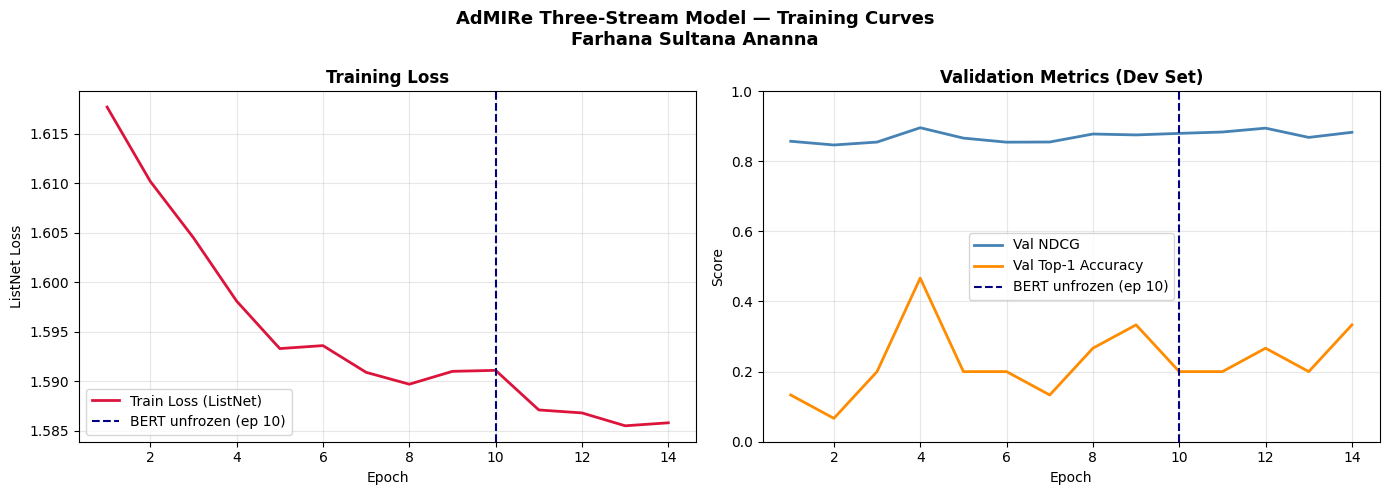


✅ Plot saved to: /content/drive/MyDrive/AllData/plots/training_curves.png

Final epoch metrics:
  Train Loss : 1.5858
  Val NDCG   : 0.8826  (best: 0.8956)
  Val Top-1  : 0.3333  (best: 0.4667)


In [ ]:
"""
================================================================================
 run_plots.py  ← RUN THIS THIRD (after run_evaluation.py)
 AdMIRe Three-Stream Model | Training Curves
 Researcher: Farhana Sultana Ananna

 What this does:
   Reads history.json saved by run_training.py
   Generates publication-quality training curve plots
   Saves PNG files to AllData/plots/ folder
================================================================================
"""
import sys
import json
import importlib

sys.path.insert(0, '/content/drive/MyDrive/AllData')
importlib.invalidate_caches()
for mod in ['config']:
    if mod in sys.modules:
        del sys.modules[mod]

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import matplotlib.pyplot as plt
from config import HISTORY_PATH, PLOTS_DIR, BERT_UNFREEZE_EP

# ─────────────────────────────────────────────────────────────────────────────
# LOAD HISTORY
# ─────────────────────────────────────────────────────────────────────────────
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

with open(HISTORY_PATH, 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)
print(f'📊 Loaded history: {len(history["train_loss"])} epochs')

# ─────────────────────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'AdMIRe Three-Stream Model — Training Curves\nFarhana Sultana Ananna',
    fontsize=13, fontweight='bold'
)

# Loss curve
axes[0].plot(epochs, history['train_loss'],
             color='crimson', lw=2, label='Train Loss (ListNet)')
axes[0].axvline(x=BERT_UNFREEZE_EP, color='navy',
                linestyle='--', lw=1.5, label=f'BERT unfrozen (ep {BERT_UNFREEZE_EP})')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('ListNet Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation metrics
axes[1].plot(epochs, history['val_ndcg'],
             color='steelblue', lw=2, label='Val NDCG')
axes[1].plot(epochs, history['val_top1'],
             color='darkorange', lw=2, label='Val Top-1 Accuracy')
axes[1].axvline(x=BERT_UNFREEZE_EP, color='navy',
                linestyle='--', lw=1.5, label=f'BERT unfrozen (ep {BERT_UNFREEZE_EP})')
axes[1].set_title('Validation Metrics (Dev Set)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_path = PLOTS_DIR / 'training_curves.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'\n✅ Plot saved to: {out_path}')
print('\nFinal epoch metrics:')
print(f'  Train Loss : {history["train_loss"][-1]:.4f}')
print(f'  Val NDCG   : {history["val_ndcg"][-1]:.4f}  '
      f'(best: {max(history["val_ndcg"]):.4f})')
print(f'  Val Top-1  : {history["val_top1"][-1]:.4f}  '
      f'(best: {max(history["val_top1"]):.4f})')

In [ ]:
"""
================================================================================
fixing the error
 run_training.py  ← RUN THIS
 AdMIRe Three-Stream Model | Final Training
 Researcher: Farhana Sultana Ananna
================================================================================
"""
import sys, json, shutil, importlib
sys.path.insert(0, '/content/drive/MyDrive/AllData')
importlib.invalidate_caches()
for mod in ['config','utils','dataset_loader','model_architecture']:
    if mod in sys.modules: del sys.modules[mod]

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from pathlib import Path

from config import (
    TRAIN_TSV, TRAIN_ROOT, DEV_TSV, DEV_ROOT,
    MODEL_PATH, HISTORY_PATH,
    LR_BASE, LR_BERT, BATCH_SIZE, EPOCHS,
    WEIGHT_DECAY, LABEL_SMOOTH_ALPHA,
    BERT_UNFREEZE_EP, BERT_UNFREEZE_LAYERS, BASE_DIR
)
from utils import listnet_loss, evaluate_loader
from dataset_loader import IdiomDataset
from model_architecture import IdiomFusionModel

# ── KEY FIX: patience must be long enough for BERT to take effect ─────────────
# BERT unfreezes at epoch 10. We need at least 15 epochs after that.
# So minimum useful run = 10 + 15 = 25 epochs before stopping.
EARLY_STOP_PATIENCE = 15   # was 10 — too aggressive, stopped before BERT could help

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')

# ─────────────────────────────────────────────────────────────────────────────
def train(use_sentence_type, save_path):
    label = 'WITH sentence type' if use_sentence_type else 'WITHOUT sentence type'
    print(f'\n{"="*60}\n  Training: {label}\n{"="*60}')

    train_df = pd.read_csv(TRAIN_TSV, sep='\t')
    dev_df   = pd.read_csv(DEV_TSV,   sep='\t')
    print(f'  Train: {len(train_df)} rows | Dev: {len(dev_df)} rows')

    train_ds = IdiomDataset(train_df, TRAIN_ROOT,
                            augment=True, use_sentence_type=use_sentence_type)
    dev_ds   = IdiomDataset(dev_df,   DEV_ROOT,
                            augment=False, use_sentence_type=use_sentence_type)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=2, pin_memory=False)
    dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=False)

    model = IdiomFusionModel().to(device)
    model.freeze_bert()

    optimizer = torch.optim.AdamW([
        {'params': model.sent_proj.parameters(),
         'lr': LR_BASE, 'weight_decay': WEIGHT_DECAY},
        {'params': model.cap_proj.parameters(),
         'lr': LR_BASE, 'weight_decay': WEIGHT_DECAY},
        {'params': model.vis_proj.parameters(),
         'lr': LR_BASE, 'weight_decay': WEIGHT_DECAY},
        {'params': model.fusion_proj.parameters(),
         'lr': LR_BASE, 'weight_decay': WEIGHT_DECAY},
        {'params': model.cross_attn.parameters(),
         'lr': LR_BASE, 'weight_decay': WEIGHT_DECAY},
        {'params': model.ranking_head.parameters(),
         'lr': LR_BASE, 'weight_decay': WEIGHT_DECAY},
    ])

    scheduler      = torch.optim.lr_scheduler.CosineAnnealingLR(
                        optimizer, T_max=EPOCHS)
    bert_added     = False
    best_ndcg      = -1.0      # ← watch NDCG only, not combined
    patience_count = 0
    local_ckpt     = Path('/content/best_model_tmp.pth')

    history = {'train_loss': [], 'val_ndcg': [], 'val_top1': []}

    for epoch in range(1, EPOCHS + 1):

        # Partial BERT unfreeze at epoch 10
        if epoch == BERT_UNFREEZE_EP and not bert_added:
            model.unfreeze_bert_last_n(BERT_UNFREEZE_LAYERS)
            bert_params = model.trainable_bert_params()
            if bert_params:
                optimizer.add_param_group({
                    'params':       bert_params,
                    'lr':           LR_BERT,
                    'weight_decay': WEIGHT_DECAY
                })
            bert_added = True
            print(f'  🔓 Epoch {epoch}: BERT last {BERT_UNFREEZE_LAYERS} '
                  f'layers unfrozen (lr={LR_BERT})')

        # Train
        model.train()
        epoch_loss = 0.0
        for batch in train_loader:
            s_ids, s_msk, imgs, c_ids, c_msk, targets = batch
            s_ids    = s_ids.to(device)
            s_msk    = s_msk.to(device)
            imgs     = imgs.to(device)
            c_ids    = c_ids.to(device)
            c_msk    = c_msk.to(device)
            targets  = targets.to(device)

            optimizer.zero_grad()
            out  = model(s_ids, s_msk, imgs, c_ids, c_msk)
            loss = listnet_loss(out, targets, alpha=LABEL_SMOOTH_ALPHA)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)

        # Validate
        val_ndcg, val_acc = evaluate_loader(model, dev_loader, device)

        history['train_loss'].append(round(avg_loss,  4))
        history['val_ndcg'].append(  round(val_ndcg,  4))
        history['val_top1'].append(  round(val_acc,   4))

        print(f'  Epoch {epoch:02d}/{EPOCHS} | '
              f'Loss: {avg_loss:.4f} | '
              f'Val NDCG: {val_ndcg:.4f} | '
              f'Val Top-1: {val_acc:.4f}')

        # ── Save checkpoint on best NDCG only ────────────────────────────
        if val_ndcg > best_ndcg:
            best_ndcg      = val_ndcg
            patience_count = 0
            torch.save(model.state_dict(), local_ckpt)
            shutil.copy(local_ckpt, save_path)
            print(f'  💾 Saved  (Val NDCG={val_ndcg:.4f})')
        else:
            patience_count += 1
            if patience_count >= EARLY_STOP_PATIENCE:
                print(f'\n  ⏹ Early stopping at epoch {epoch} '
                      f'(no NDCG improvement for {EARLY_STOP_PATIENCE} epochs).')
                break

    print(f'\n  Best Val NDCG : {best_ndcg:.4f}')
    print(f'  Best Val Top-1: {max(history["val_top1"]):.4f}')
    print(f'  Model saved to: {save_path}')
    return history

# ─────────────────────────────────────────────────────────────────────────────
# Pass 1 — WITH sentence type  (main model)
history_with = train(
    use_sentence_type=True,
    save_path=MODEL_PATH
)

# Save history for plots
with open(HISTORY_PATH, 'w') as f:
    json.dump(history_with, f)
print(f'\nHistory saved to: {HISTORY_PATH}')

# Pass 2 — WITHOUT sentence type  (ablation)
history_without = train(
    use_sentence_type=False,
    save_path=BASE_DIR / 'best_model_no_st.pth'
)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print('  TRAINING SUMMARY')
print(f'{"="*60}')
print(f'  With ST    — Best Val NDCG: {max(history_with["val_ndcg"]):.4f} | '
      f'Best Val Top-1: {max(history_with["val_top1"]):.4f}')
print(f'  Without ST — Best Val NDCG: {max(history_without["val_ndcg"]):.4f} | '
      f'Best Val Top-1: {max(history_without["val_top1"]):.4f}')
print(f'{"="*60}')
print('\n✅ DONE — next run run_evaluation.py')

Mounted at /content/drive
✅ Device: cuda

  Training: WITH sentence type
  Train: 70 rows | Dev: 15 rows


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 01/50 | Loss: 1.6195 | Val NDCG: 0.8752 | Val Top-1: 0.2000
  💾 Saved  (Val NDCG=0.8752)
  Epoch 02/50 | Loss: 1.6111 | Val NDCG: 0.8996 | Val Top-1: 0.4667
  💾 Saved  (Val NDCG=0.8996)
  Epoch 03/50 | Loss: 1.6069 | Val NDCG: 0.8766 | Val Top-1: 0.2000
  Epoch 04/50 | Loss: 1.5996 | Val NDCG: 0.8679 | Val Top-1: 0.2000
  Epoch 05/50 | Loss: 1.6015 | Val NDCG: 0.8624 | Val Top-1: 0.2667
  Epoch 06/50 | Loss: 1.5925 | Val NDCG: 0.8974 | Val Top-1: 0.3333
  Epoch 07/50 | Loss: 1.5932 | Val NDCG: 0.8939 | Val Top-1: 0.4667
  Epoch 08/50 | Loss: 1.5914 | Val NDCG: 0.8846 | Val Top-1: 0.2667
  Epoch 09/50 | Loss: 1.5901 | Val NDCG: 0.8666 | Val Top-1: 0.2667
  🔓 Epoch 10: BERT last 3 layers unfrozen (lr=2e-05)
  Epoch 10/50 | Loss: 1.5924 | Val NDCG: 0.9080 | Val Top-1: 0.2667
  💾 Saved  (Val NDCG=0.9080)
  Epoch 11/50 | Loss: 1.5909 | Val NDCG: 0.8631 | Val Top-1: 0.1333
  Epoch 12/50 | Loss: 1.5899 | Val NDCG: 0.8798 | Val Top-1: 0.3333
  Epoch 13/50 | Loss: 1.5888 | Val NDCG: 0.8

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 01/50 | Loss: 1.6212 | Val NDCG: 0.8444 | Val Top-1: 0.0667
  💾 Saved  (Val NDCG=0.8444)
  Epoch 02/50 | Loss: 1.6081 | Val NDCG: 0.8732 | Val Top-1: 0.2667
  💾 Saved  (Val NDCG=0.8732)
  Epoch 03/50 | Loss: 1.6081 | Val NDCG: 0.8525 | Val Top-1: 0.1333
  Epoch 04/50 | Loss: 1.6023 | Val NDCG: 0.8711 | Val Top-1: 0.2667
  Epoch 05/50 | Loss: 1.5977 | Val NDCG: 0.8690 | Val Top-1: 0.3333
  Epoch 06/50 | Loss: 1.5929 | Val NDCG: 0.9026 | Val Top-1: 0.4667
  💾 Saved  (Val NDCG=0.9026)
  Epoch 07/50 | Loss: 1.5920 | Val NDCG: 0.8749 | Val Top-1: 0.2667
  Epoch 08/50 | Loss: 1.5906 | Val NDCG: 0.8822 | Val Top-1: 0.4000
  Epoch 09/50 | Loss: 1.5876 | Val NDCG: 0.8842 | Val Top-1: 0.4667
  🔓 Epoch 10: BERT last 3 layers unfrozen (lr=2e-05)
  Epoch 10/50 | Loss: 1.5885 | Val NDCG: 0.8765 | Val Top-1: 0.4000
  Epoch 11/50 | Loss: 1.5874 | Val NDCG: 0.8553 | Val Top-1: 0.2000
  Epoch 12/50 | Loss: 1.5878 | Val NDCG: 0.8663 | Val Top-1: 0.3333
  Epoch 13/50 | Loss: 1.5863 | Val NDCG: 0.8

In [ ]:
"""
================================================================================
 run_evaluation.py  ← RUN THIS SECOND (after run_training.py)
 AdMIRe Three-Stream Model | Test Evaluation
 Researcher: Farhana Sultana Ananna

 What this does:
   Loads best_model.pth (saved by run_training.py)
   Evaluates on the labeled test set (15 rows)
   Prints final Top-1 Accuracy and NDCG
   Tests both WITH and WITHOUT sentence type

 These are your final paper numbers.
================================================================================
"""
import sys
import importlib

sys.path.insert(0, '/content/drive/MyDrive/AllData')
importlib.invalidate_caches()
for mod in ['config', 'utils', 'dataset_loader', 'model_architecture']:
    if mod in sys.modules:
        del sys.modules[mod]

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import torch
import pandas as pd
from torch.utils.data import DataLoader

# Sourced cleanly from config
from config import TEST_TSV, TEST_ROOT, BATCH_SIZE, BASE_DIR
from utils import evaluate_loader
from dataset_loader import IdiomDataset
from model_architecture import IdiomFusionModel

# Resolve the name mismatch safely
MODEL_CHECKPOINT_PATH = BASE_DIR / 'best_model.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')

# ─────────────────────────────────────────────────────────────────────────────
# LOAD MODEL
# ─────────────────────────────────────────────────────────────────────────────
print(f'\nLoading checkpoint from: {MODEL_CHECKPOINT_PATH}')
model = IdiomFusionModel().to(device)
state = torch.load(MODEL_CHECKPOINT_PATH, map_location=device)
model.load_state_dict(state)
model.eval()
print('✅ Model loaded successfully.')

# ─────────────────────────────────────────────────────────────────────────────
# LOAD TEST DATA
# ─────────────────────────────────────────────────────────────────────────────
test_df = pd.read_csv(TEST_TSV, sep='\t')
print(f'📦 Test rows: {len(test_df)}')

results = {}

# Testing both configurations back-to-back
for use_st, label in [(True,  'With Sentence Type'),
                       (False, 'Without Sentence Type')]:
    ds     = IdiomDataset(test_df, TEST_ROOT,
                          augment=False, use_sentence_type=use_st)
    loader = DataLoader(ds, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=False)

    ndcg, acc = evaluate_loader(model, loader, device)
    results[label] = (ndcg, acc)
    print(f'  {label:25s} → NDCG: {ndcg:.4f} | Top-1 Acc: {acc:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY REPORT
# ─────────────────────────────────────────────────────────────────────────────
print(f'\n{"─"*55}')
print('  FINAL TEST RESULTS')
print(f'{"─"*55}')
print(f'  {"Configuration":<25} | {"NDCG":>8} | {"Top-1 Acc":>10}')
print(f'{"─"*55}')
for label, (ndcg, acc) in results.items():
    print(f'  {label:<25} | {ndcg:>8.4f} | {acc:>10.4f}')
print(f'{"─"*55}')
print('\n✅ DONE — next run run_plots.py')

Mounted at /content/drive
✅ Device: cuda

Loading checkpoint from: /content/drive/MyDrive/AllData/best_model.pth


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded successfully.
📦 Test rows: 15
  With Sentence Type        → NDCG: 0.8800 | Top-1 Acc: 0.3333
  Without Sentence Type     → NDCG: 0.8768 | Top-1 Acc: 0.2667

───────────────────────────────────────────────────────
  FINAL TEST RESULTS
───────────────────────────────────────────────────────
  Configuration             |     NDCG |  Top-1 Acc
───────────────────────────────────────────────────────
  With Sentence Type        |   0.8800 |     0.3333
  Without Sentence Type     |   0.8768 |     0.2667
───────────────────────────────────────────────────────

✅ DONE — next run run_plots.py


Mounted at /content/drive
📊 Loaded history: 25 epochs


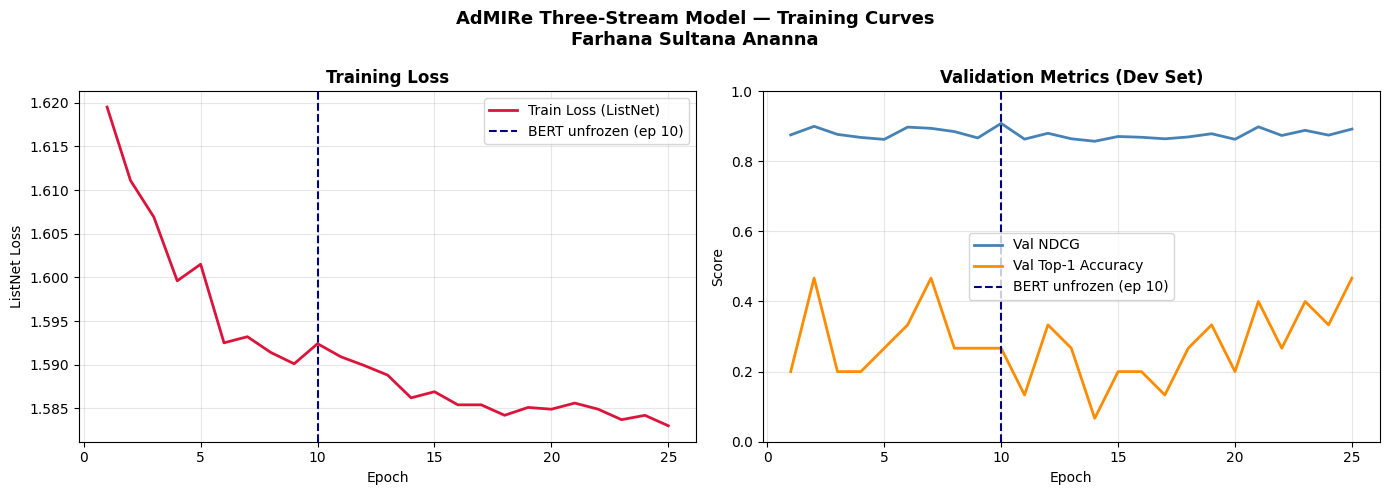


✅ Plot saved to: /content/drive/MyDrive/AllData/plots/training_curves.png

Final epoch metrics:
  Train Loss : 1.5830
  Val NDCG   : 0.8918  (best: 0.9080)
  Val Top-1  : 0.4667  (best: 0.4667)


In [ ]:
"""
================================================================================
 run_plots.py  ← RUN THIS THIRD (after run_evaluation.py)
 AdMIRe Three-Stream Model | Training Curves
 Researcher: Farhana Sultana Ananna

 What this does:
   Reads history.json saved by run_training.py
   Generates publication-quality training curve plots
   Saves PNG files to AllData/plots/ folder
================================================================================
"""
import sys
import json
import importlib

sys.path.insert(0, '/content/drive/MyDrive/AllData')
importlib.invalidate_caches()
for mod in ['config']:
    if mod in sys.modules:
        del sys.modules[mod]

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import matplotlib.pyplot as plt
from config import HISTORY_PATH, PLOTS_DIR, BERT_UNFREEZE_EP

# ─────────────────────────────────────────────────────────────────────────────
# LOAD HISTORY
# ─────────────────────────────────────────────────────────────────────────────
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

with open(HISTORY_PATH, 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)
print(f'📊 Loaded history: {len(history["train_loss"])} epochs')

# ─────────────────────────────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'AdMIRe Three-Stream Model — Training Curves\nFarhana Sultana Ananna',
    fontsize=13, fontweight='bold'
)

# Loss curve
axes[0].plot(epochs, history['train_loss'],
             color='crimson', lw=2, label='Train Loss (ListNet)')
axes[0].axvline(x=BERT_UNFREEZE_EP, color='navy',
                linestyle='--', lw=1.5, label=f'BERT unfrozen (ep {BERT_UNFREEZE_EP})')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('ListNet Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation metrics
axes[1].plot(epochs, history['val_ndcg'],
             color='steelblue', lw=2, label='Val NDCG')
axes[1].plot(epochs, history['val_top1'],
             color='darkorange', lw=2, label='Val Top-1 Accuracy')
axes[1].axvline(x=BERT_UNFREEZE_EP, color='navy',
                linestyle='--', lw=1.5, label=f'BERT unfrozen (ep {BERT_UNFREEZE_EP})')
axes[1].set_title('Validation Metrics (Dev Set)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_path = PLOTS_DIR / 'training_curves.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'\n✅ Plot saved to: {out_path}')
print('\nFinal epoch metrics:')
print(f'  Train Loss : {history["train_loss"][-1]:.4f}')
print(f'  Val NDCG   : {history["val_ndcg"][-1]:.4f}  '
      f'(best: {max(history["val_ndcg"]):.4f})')
print(f'  Val Top-1  : {history["val_top1"][-1]:.4f}  '
      f'(best: {max(history["val_top1"]):.4f})')

In [1]:
import json

file_name = '7july.ipynb'

# Load the notebook
with open(file_name, 'r', encoding='utf-8') as f:
    nb = json.load(f)

# Remove the corrupted widgets metadata if it exists
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']
    print("Widget metadata removed!")

# Save the fixed notebook
with open(file_name, 'w', encoding='utf-8') as f:
    json.dump(nb, f, indent=1)

FileNotFoundError: [Errno 2] No such file or directory: '7july.ipynb'